# 0 — Data Preparation

**Project:** Syllabus Policy Stance Detection  
**Author:** Charitha  
**Purpose:** This notebook reads the raw annotated CSV, cleans and standardizes the labels, and produces a clean dataset of only policy-relevant sentences.

---

## What this notebook does (step by step):
1. Load the raw annotated file (`policy_annotation_sample_1000.csv`)
2. Inspect the data 
3. Filter to only policy-relevant sentences
4. Clean and standardize stance labels
5. Handle edge cases (doubtful, nulls, whitespace)
6. Visualize the final distribution
7. Save the clean file as `policy_relevant_clean.csv`

---

## Import Libraries

We only need two libraries for data preparation:
- `pandas` — for reading, cleaning, and saving tabular data
- `matplotlib` + `seaborn` — for visualizing the label distribution

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Define File Paths

In [4]:
RAW_DATA_PATH = '../data/interim/policy_annotation_sample_1000.csv'
OUTPUT_PATH = '../data/processed/policy_relevant_clean.csv'

# Make sure the output folder exists (creates it if it doesn't)
os.makedirs('../data/processed', exist_ok=True)

print(f'Input  : {RAW_DATA_PATH}')
print(f'Output : {OUTPUT_PATH}')

Input  : ../data/interim/policy_annotation_sample_1000.csv
Output : ../data/processed/policy_relevant_clean.csv


## Load the Raw Data

We use `encoding='latin1'` because the file contains some special characters that the default UTF-8 encoding cannot read. We also only keep the first 4 columns — the rest are empty artifact columns from Excel.

In [5]:
# Load raw CSV
df_raw = pd.read_csv(RAW_DATA_PATH, encoding='latin1')

# Keep only the 4 meaningful columns
df_raw = df_raw.iloc[:, :4]
df_raw.columns = ['sentence', 'policy_relevant', 'stance', 'notes']

print('Raw data loaded!')
print(f'Total rows: {len(df_raw)}')
print(f'Columns: {df_raw.columns.tolist()}')
print()
df_raw.head(5)

Raw data loaded!
Total rows: 1033
Columns: ['sentence', 'policy_relevant', 'stance', 'notes']



,sentence,policy_relevant,stance,notes
0,Logo Your posting of the logo or related pictu...,0.0,NaN,NaN
1,IMPORTANT: Note that Wikipedia is reliable for...,1.0,conditional,NaN
2,Available at: http://en.wikipedia.org/wiki/Wik...,0.0,NaN,NaN
3,Use of sites such as Wikipedia are not allowed...,1.0,dis,NaN
4,"Recommended reading, ""https://en.wikipedia.org...",0.0,NaN,NaN


## Inspect the Raw Data

In [6]:
print('=== POLICY RELEVANCE DISTRIBUTION ===')
print(df_raw['policy_relevant'].value_counts())
print()

print('=== RAW STANCE LABELS (before cleaning) ===')
# Use dropna=False so we can see NaN counts too
print(df_raw['stance'].value_counts(dropna=False))
print()

print('=== NULL CHECK ===')
print(df_raw.isnull().sum())
print()

print('=== DATA TYPES ===')
print(df_raw.dtypes)

=== POLICY RELEVANCE DISTRIBUTION ===
policy_relevant
0.0    667
1.0    355
Name: count, dtype: int64

=== RAW STANCE LABELS (before cleaning) ===
stance
NaN             677
dis             293
enc              28
conditional      27
conditional       7
doubtful          1
Name: count, dtype: int64

=== NULL CHECK ===
sentence            22
policy_relevant     11
stance             677
notes              983
dtype: int64

=== DATA TYPES ===
sentence            object
policy_relevant    float64
stance              object
notes               object
dtype: object


## Filter to Policy-Relevant Sentences Only

**Why:** Our task is stance classification of policy sentences. Non-policy sentences (label = 0) are not relevant to our model. We isolate only the sentences where `policy_relevant == 1`.

**Independent variable:** sentence text  
**Dependent variable:** stance label  
**Unit of analysis:** one sentence

In [7]:
# Filter to policy-relevant sentences only
df_policy = df_raw[df_raw['policy_relevant'] == 1.0].copy()

# Keep only the columns we need for modeling
df_policy = df_policy[['sentence', 'stance']].reset_index(drop=True)

print(f'Total sentences         : {len(df_raw)}')
print(f'Policy-relevant         : {len(df_policy)}')
print(f'Non-policy (excluded)   : {len(df_raw) - len(df_policy)}')

Total sentences         : 1033
Policy-relevant         : 355
Non-policy (excluded)   : 678


## Clean and Standardize Stance Labels

The raw labels have inconsistencies from manual annotation:
- `'dis'` should be `'discouraging'`
- `'enc'` should be `'encouraging'`
- `' conditional'` has a leading space,needs stripping
- `'doubtful'` one ambiguous sentence, reassigned to `'conditional'`

**Why standardize?** The model reads these labels as strings. `'dis'` and `'discouraging'` would be treated as two completely different classes.

In [8]:
# Step 1: Strip leading/trailing whitespace from all labels
df_policy['stance'] = df_policy['stance'].str.strip()

# Step 2: Map abbreviated/inconsistent labels to standard names
label_mapping = {
    'dis'      : 'discouraging',   # abbreviated label
    'enc'      : 'encouraging',    # abbreviated label
    'doubtful' : 'conditional'     # ambiguous → reassigned to conditional
}
df_policy['stance'] = df_policy['stance'].replace(label_mapping)

# Step 3: Verify — show cleaned distribution
print('=== CLEANED STANCE DISTRIBUTION ===')
print(df_policy['stance'].value_counts())
print()

# Step 4: Check for any remaining unexpected labels
valid_labels = {'discouraging', 'conditional', 'encouraging'}
unexpected = df_policy[~df_policy['stance'].isin(valid_labels)]
print(f'Unexpected labels found: {len(unexpected)}')
if len(unexpected) > 0:
    print(unexpected)

=== CLEANED STANCE DISTRIBUTION ===
stance
discouraging    293
conditional      34
encouraging      28
Name: count, dtype: int64

Unexpected labels found: 0


## Handle Nulls

Policy-relevant sentences should all have a stance label. If any are missing, we need to know and handle them.

In [9]:
# Check for null stances
null_stance = df_policy['stance'].isnull().sum()
print(f'Rows with null stance: {null_stance}')

if null_stance > 0:
    print('\nRows with missing stance labels:')
    print(df_policy[df_policy['stance'].isnull()])
    # Drop them we cannot train on unlabeled data
    df_policy = df_policy.dropna(subset=['stance']).reset_index(drop=True)
    print(f'\nAfter dropping nulls: {len(df_policy)} rows remain')
else:
    print('No nulls found. All policy sentences have stance labels.')

# Also check for empty strings
empty_stance = (df_policy['stance'] == '').sum()
print(f'Rows with empty stance string: {empty_stance}')

Rows with null stance: 0
No nulls found. All policy sentences have stance labels.
Rows with empty stance string: 0


## Clean Sentence Text

Basic text normalization on the sentence column. We do not do aggressive cleaning here (like removing stopwords) that happens inside the model pipeline. Here we just fix encoding artifacts and extra whitespace.

In [10]:
# Strip leading/trailing whitespace from sentences
df_policy['sentence'] = df_policy['sentence'].str.strip()

# Remove rows where sentence is empty or null
df_policy = df_policy[df_policy['sentence'].notna()]
df_policy = df_policy[df_policy['sentence'] != '']
df_policy = df_policy.reset_index(drop=True)

# Show sentence length stats — useful context for modeling
df_policy['sentence_length'] = df_policy['sentence'].apply(lambda x: len(x.split()))

print('=== SENTENCE LENGTH STATISTICS (word count) ===')
print(df_policy.groupby('stance')['sentence_length'].describe().round(1))
print()
print(f'Final dataset size: {len(df_policy)} sentences')

=== SENTENCE LENGTH STATISTICS (word count) ===
              count  mean    std   min   25%   50%   75%     max
stance                                                          
conditional    34.0  58.0   55.5  11.0  25.5  39.0  65.8   255.0
discouraging  292.0  75.2  147.1   3.0  18.8  40.0  71.0  1326.0
encouraging    28.0  54.4   76.5  11.0  16.8  26.5  39.8   334.0

Final dataset size: 354 sentences


## Visualize the Final Label Distribution

Always visualize your data before modeling. This chart directly illustrates the **class imbalance problem** that motivates my balanced sampling strategy.

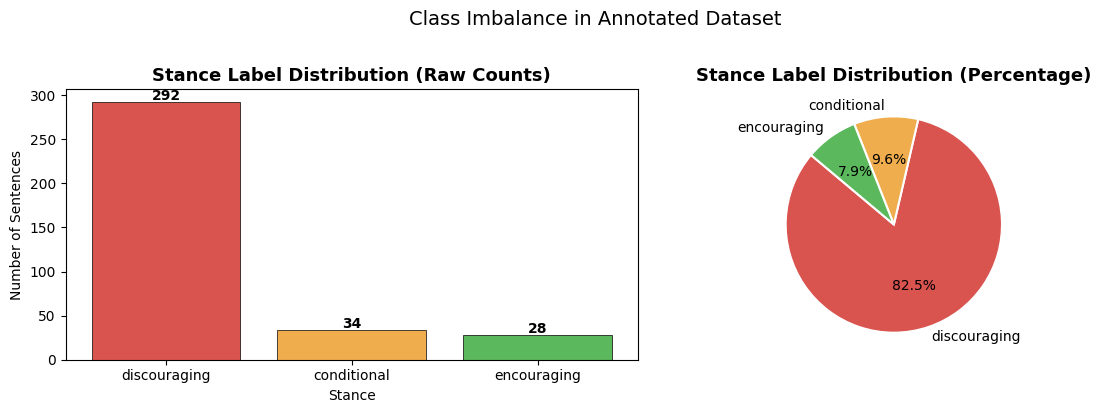

Figure saved to ../analysis/label_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Plot 1: Raw counts ──────────────────────────────────────────────────
stance_counts = df_policy['stance'].value_counts()
colors = ['#d9534f', '#f0ad4e', '#5cb85c']  # red, orange, green

axes[0].bar(stance_counts.index, stance_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Stance Label Distribution (Raw Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stance')
axes[0].set_ylabel('Number of Sentences')
for i, (label, count) in enumerate(stance_counts.items()):
    axes[0].text(i, count + 2, str(count), ha='center', fontweight='bold')

# ── Plot 2: Percentage breakdown ────────────────────────────────────────
stance_pct = stance_counts / stance_counts.sum() * 100
axes[1].pie(
    stance_pct.values,
    labels=stance_pct.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Stance Label Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance in Annotated Dataset', fontsize=14, y=1.02)
plt.tight_layout()

# Save the figure
os.makedirs('../analysis', exist_ok=True)
plt.savefig('../analysis/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ../analysis/label_distribution.png')

## Final Summary Statistics

In [12]:
print('=' * 50)
print('       FINAL DATASET SUMMARY')
print('=' * 50)
print(f'Total policy-relevant sentences : {len(df_policy)}')
print()

for stance, group in df_policy.groupby('stance'):
    pct = len(group) / len(df_policy) * 100
    avg_len = group['sentence_length'].mean()
    print(f'  {stance:<15} : {len(group):>4} sentences ({pct:.1f}%) | avg {avg_len:.0f} words/sentence')

print()
print('NOTE: Dataset is heavily imbalanced.')
print('Discouraging dominates at ~83% of all policy sentences.')
print('Balanced sampling will be applied in the modeling notebook.')
print('=' * 50)

       FINAL DATASET SUMMARY
Total policy-relevant sentences : 354

  conditional     :   34 sentences (9.6%) | avg 58 words/sentence
  discouraging    :  292 sentences (82.5%) | avg 75 words/sentence
  encouraging     :   28 sentences (7.9%) | avg 54 words/sentence

NOTE: Dataset is heavily imbalanced.
Discouraging dominates at ~83% of all policy sentences.
Balanced sampling will be applied in the modeling notebook.


## Save the Clean Dataset

We save two versions:
1. **`policy_relevant_clean.csv`** — the full 355-row dataset, used for training
2. **`policy_relevant_clean_with_stats.csv`** — same but includes sentence_length column, useful for analysis

In [13]:
# Version 1: Clean minimal dataset for modeling (sentence + stance only)
df_model = df_policy[['sentence', 'stance']].copy()
df_model.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
print(f'Saved: {OUTPUT_PATH}')
print(f'Rows: {len(df_model)}')
print(f'Columns: {df_model.columns.tolist()}')
print()

# Version 2: With stats for analysis
stats_path = '../data/processed/policy_relevant_with_stats.csv'
df_policy.to_csv(stats_path, index=False, encoding='utf-8')
print(f'Saved: {stats_path}')

print()
print('Data preparation complete!')
print('Next step: Open 01_baseline_models.ipynb')

Saved: ../data/processed/policy_relevant_clean.csv
Rows: 354
Columns: ['sentence', 'stance']

Saved: ../data/processed/policy_relevant_with_stats.csv

Data preparation complete!
Next step: Open 01_baseline_models.ipynb


## Sanity Check (Load and Verify Saved File)

In [14]:
# Reload and verify
df_verify = pd.read_csv(OUTPUT_PATH)

print('=== VERIFICATION: Reloaded from disk ===')
print(f'Shape: {df_verify.shape}')
print(f'Columns: {df_verify.columns.tolist()}')
print()
print('Stance distribution:')
print(df_verify['stance'].value_counts())
print()
print('First 3 rows:')
print(df_verify.head(3))
print()
print('All good! policy_relevant_clean.csv is ready for modeling.')

=== VERIFICATION: Reloaded from disk ===
Shape: (354, 2)
Columns: ['sentence', 'stance']

Stance distribution:
stance
discouraging    292
conditional      34
encouraging      28
Name: count, dtype: int64

First 3 rows:
                                            sentence        stance
0  IMPORTANT: Note that Wikipedia is reliable for...   conditional
1  Use of sites such as Wikipedia are not allowed...  discouraging
2  Thus, do not use Wikipedia as your primary sou...   conditional

All good! policy_relevant_clean.csv is ready for modeling.
